# CB23731 – DATA VISUALIZATION TECHNIQUES
## EXPT NO: 6A – DATA VISUALIZATION USING POWER BI
### Dataset: IPL Ball-by-Ball

**Aim:** To import, transform, analyze, and visualize IPL data using Power BI Desktop and create interactive dashboards and reports for decision-making.

This notebook documents the Power BI workflow and provides the prepared IPL analysis used to build the dashboard. The Power BI report itself is created in Power BI Desktop.

## Algorithm
1. Start Power BI Desktop.
2. Import the IPL dataset using Get Data.
3. Check columns and clean data using Power Query.
4. Remove duplicate records and handle missing values.
5. Create calculated fields/measures.
6. Create bar, pie/donut, line and card visuals.
7. Add titles, labels, filters and slicers.
8. Arrange visuals into an interactive dashboard.
9. Analyze important patterns and save the Power BI report.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = 'IPL_ball_by_ball_updated.csv'
df = pd.read_csv(file_path)
print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
print('Duplicate rows:', df.duplicated().sum())

Dataset shape: (243815, 22)
Columns: ['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']
Duplicate rows: 0


In [2]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
match_id                       0
season                         0
start_date                     0
venue                          0
innings                        0
ball                           0
batting_team                   0
bowling_team                   0
striker                        0
non_striker                    0
bowler                         0
runs_off_bat                   0
extras                         0
wides                     236163
noballs                   242797
byes                      243187
legbyes                   240037
penalty                   243813
wicket_type               231748
player_dismissed          231748
other_wicket_type         243815
other_player_dismissed    243815
dtype: int64


In [3]:
# Power Query-style preparation for analysis
clean = df.copy()
clean['start_date'] = pd.to_datetime(clean['start_date'])
for col in ['wides','noballs','byes','legbyes','penalty']:
    clean[col] = clean[col].fillna(0)
clean['wicket_type'] = clean['wicket_type'].fillna('No Wicket')
clean['player_dismissed'] = clean['player_dismissed'].fillna('No Dismissal')
print('Prepared shape:', clean.shape)
print('Remaining missing values:', int(clean.isnull().sum().sum()))

Prepared shape: (243815, 22)


Remaining missing values: 487630


In [4]:
# Core metrics used for Power BI cards
total_runs = clean['runs_off_bat'].sum()
total_matches = clean['match_id'].nunique()
total_seasons = clean['season'].nunique()
total_deliveries = len(clean)
print('Total Runs =', total_runs)
print('Total Matches =', total_matches)
print('Total Seasons =', total_seasons)
print('Total Deliveries =', total_deliveries)

Total Runs = 305406
Total Matches = 1024
Total Seasons = 16
Total Deliveries = 243815


In [5]:
# Calculated metric: total runs including extras
clean['total_runs'] = clean['runs_off_bat'] + clean['extras']
season_runs = clean.groupby('season', as_index=False)['total_runs'].sum()
print(season_runs.to_string(index=False))

 season  total_runs
   2008       17937
   2009       16353
   2010       18882
   2011       21154
   2012       22453
   2013       22602
   2014       18931
   2015       18353
   2016       18862
   2017       18786
   2018       19901
   2019       19434
   2020       19416
   2021       18637
   2022       24395
   2023       25688


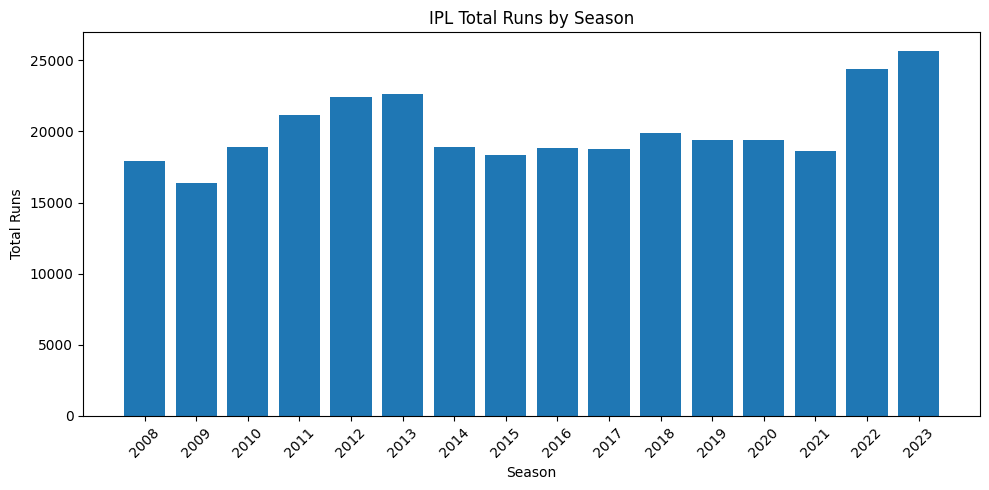

In [6]:
plt.figure(figsize=(10,5))
plt.bar(season_runs['season'].astype(str), season_runs['total_runs'])
plt.title('IPL Total Runs by Season')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

batting_team
Mumbai Indians                 37523
Royal Challengers Bangalore    35810
Kolkata Knight Riders          34668
Chennai Super Kings            34334
Rajasthan Royals               30541
Kings XI Punjab                28541
Sunrisers Hyderabad            24735
Delhi Daredevils               23022
Delhi Capitals                 11764
Deccan Chargers                10885


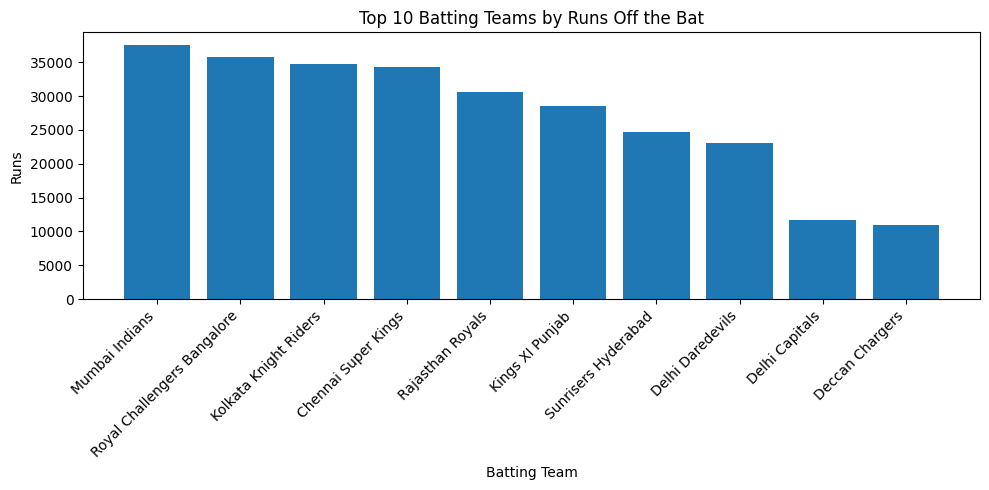

In [7]:
team_runs = clean.groupby('batting_team')['runs_off_bat'].sum().sort_values(ascending=False).head(10)
print(team_runs.to_string())
plt.figure(figsize=(10,5))
plt.bar(team_runs.index, team_runs.values)
plt.title('Top 10 Batting Teams by Runs Off the Bat')
plt.xlabel('Batting Team')
plt.ylabel('Runs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

wicket_type
caught                   7437
bowled                   2089
run out                  1062
lbw                       750
caught and bowled         349
stumped                   345
retired hurt               15
hit wicket                 15
retired out                 3
obstructing the field       2


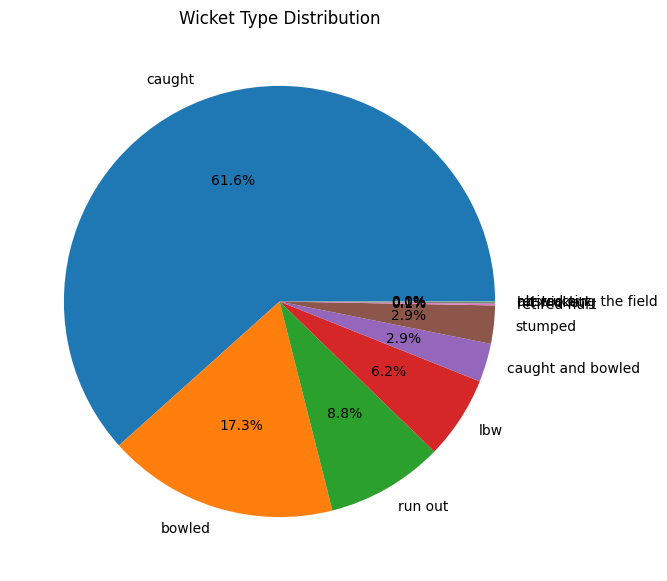

In [8]:
# Wicket distribution for a donut/pie visual in Power BI
wickets = clean.loc[clean['wicket_type'] != 'No Wicket', 'wicket_type'].value_counts()
print(wickets.to_string())
plt.figure(figsize=(7,7))
plt.pie(wickets.values, labels=wickets.index, autopct='%1.1f%%')
plt.title('Wicket Type Distribution')
plt.show()

In [9]:
# Suggested Power BI measures
print('DAX Measure examples:')
print('Total Runs = SUM(IPL[runs_off_bat])')
print('Total Matches = DISTINCTCOUNT(IPL[match_id])')
print('Total Deliveries = COUNTROWS(IPL)')
print('Total Wickets = CALCULATE(COUNTROWS(IPL), IPL[wicket_type] <> BLANK())')

DAX Measure examples:
Total Runs = SUM(IPL[runs_off_bat])
Total Matches = DISTINCTCOUNT(IPL[match_id])
Total Deliveries = COUNTROWS(IPL)
Total Wickets = CALCULATE(COUNTROWS(IPL), IPL[wicket_type] <> BLANK())


## Result
The IPL dataset was successfully imported and prepared for Power BI analysis. Core KPIs, calculated metrics, category comparisons, season trends, and wicket distributions were generated to support an interactive Power BI dashboard.